In [1]:
import numpy as np
import imageio.v3 as io
import matplotlib.pyplot as plt
import pandas as pd
from concurrent.futures import ThreadPoolExecutor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

In [2]:
from lib.domain import Feature
from lib.features.haralick import HaralickFeatureExtractor
from lib.features.lbp import LBPFeatureExtractor

### Extração de features e dataset

In [3]:
'''
Função utilitaria para ler as imagens, extrair features
e gerar os datasets para o modelo.

Usei a biblioteca de concorrencia pra acelerar as coisas,
pq algumas features estavam meio lentas.
'''
def generate_dataset(df: pd.DataFrame, extractor):
    def worker(r: pd.Series) -> tuple[str, Feature]:
        img = io.imread(f"./data/{r["filename"]}")
        features = extractor(img)
    
        return (r["class_name"], features)
    
    X: list[Feature] = []
    y: list[str] = []
    
    with ThreadPoolExecutor(max_workers=5) as ex:
        results = ex.map(worker, [row for index, row in df.iterrows()])
        for result in results:
            X.append(result[1])
            y.append(result[0])
            
    return X, y

In [4]:
'''
Função que divide os datasets em treino, teste e validação.
Tive que adaptar um pouco pros casos de poucas imgs (
mesmo filtrando > 3, ainda tava meio ruim pra separar)
'''
def generate_cases(X: list[Feature], y: list[str]):
    total = len(y)
    n_classes = len(np.unique(y))

    # Tamanho mínimo do teste
    test_size = max(int(total * 0.10), n_classes)

    # Separa o Teste
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    # Tamanho minimo val
    val_size = max(int(total * 0.10), n_classes)

    # Separa val e treino
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val,
        y_train_val,
        test_size=val_size,
        random_state=42,
        stratify=y_train_val,
    )

    return X_train, X_val, X_test, y_train, y_val, y_test

In [5]:
df = pd.read_csv("./data/metadata.csv")

# Remoção de pets < 3 fotos
counts = df["class_id"].value_counts()
valid_classes = counts[counts >= 3].index

df = df[df["class_id"].isin(valid_classes)]
df.head()

,class_id,class_name,filename
0,0,simba,simba/00000.jpg
1,0,simba,simba/00001.jpg
2,0,simba,simba/00002.jpg
3,0,simba,simba/00003.jpg
4,0,simba,simba/00004.jpg


### Descritor: Haralick

In [6]:
# Haralick puro
X, y = generate_dataset(df, HaralickFeatureExtractor.apply)
X_train, X_val, X_test, y_train, y_val, y_test = generate_cases(X, y)

In [7]:
clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")

# Treino
clf.fit(X_train, y_train)

y_val_pred = clf.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)
print(f"Acurácia na Validação: {val_acc:.2%}")

# Usar modelo no test
y_test_pred = clf.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"Acurácia Final no Teste: {test_acc:.2%}")

# Relatório
print("\nRelatório de Classificação no Teste:")
print(classification_report(y_test, y_test_pred, zero_division=0))

Acurácia na Validação: 7.89%
Acurácia Final no Teste: 2.63%

Relatório de Classificação no Teste:
                     precision    recall  f1-score   support

         ada_pipoca       0.00      0.00      0.00         1
               alan       0.00      0.00      0.00         1
              bella       0.00      0.00      0.00         0
              billy       0.00      0.00      0.00         1
      billy_franzen       0.00      0.00      0.00         2
                bob       0.00      0.00      0.00         1
              chico       0.00      0.00      0.00         0
              daisy       0.00      0.00      0.00         2
            de_enzo       0.00      0.00      0.00         1
          de_victor       0.00      0.00      0.00         2
             emilia       0.00      0.00      0.00         1
          francisco       0.00      0.00      0.00         1
            hamtaro       0.00      0.00      0.00         2
               haru       0.00      0.00      0

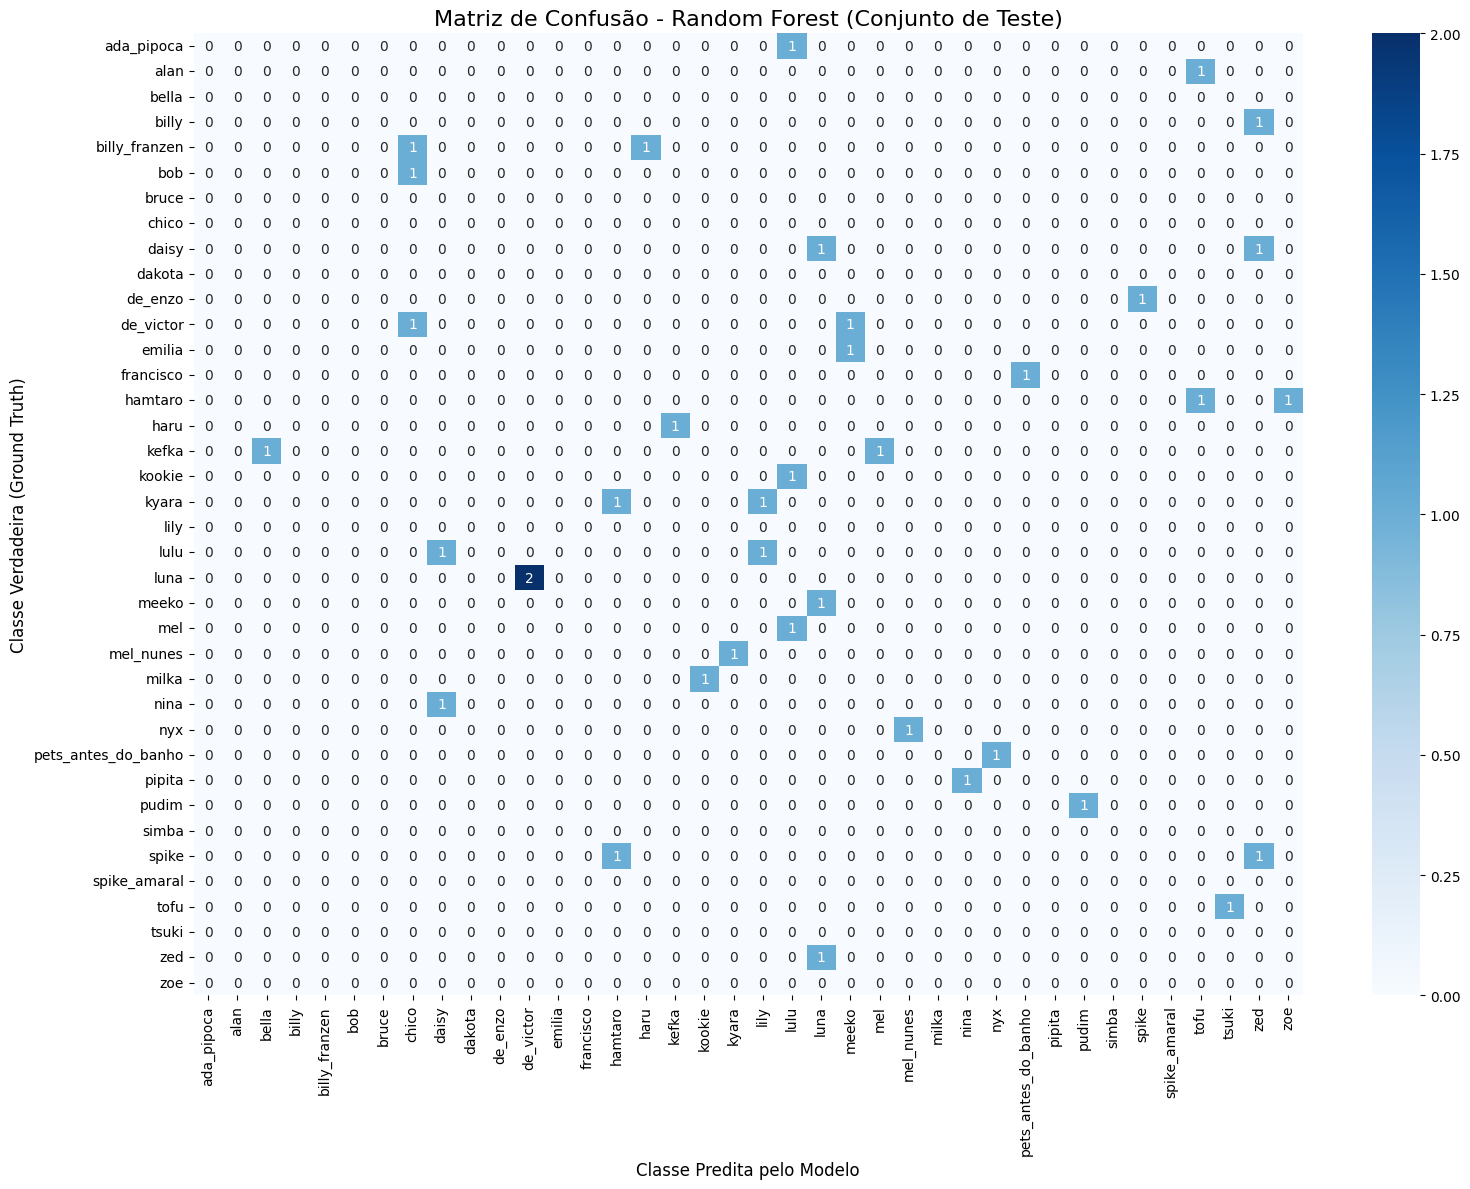

In [8]:
unique_classes = clf.classes_

cm = confusion_matrix(y_test, y_test_pred, labels=unique_classes)
plt.figure(figsize=(16, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=unique_classes,
    yticklabels=unique_classes,
    cbar=True,
)

plt.title("Matriz de Confusão - Random Forest (Conjunto de Teste)", fontsize=16)
plt.ylabel("Classe Verdadeira (Ground Truth)", fontsize=12)
plt.xlabel("Classe Predita pelo Modelo", fontsize=12)
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()